# DCT Laboratory — Volume II, Chapter 12
## Multi-Objective Enterprise Optimization
**Seed `26212`** · Companion to the chapter and AXIOM Module **AXIOM-12 (Vol. II)**

When the enterprise wants several things at once. Three acts: **Pareto
dominance sorted by hand** over eight candidate policies (five efficient,
three dominated), the **scalarization gap exhibited** — policy D sits in a
non-convex dent of the frontier that *no weighted sum can select*, but a
weighted-Chebyshev compromise finds it — and a **continuous frontier** where
the Trade-Off Theorem's slope identity is verified point by point.
Mirrored in `DCT_V2_Ch12_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26212
NAMES = list("ABCDEFGH")
PTS = {"A":(2,9.0),"B":(4,8.0),"C":(5,5.0),"D":(6,6.5),"E":(7,4.0),"F":(8,6.0),"G":(9,2.0),"H":(3,6.0)}
def dominated(name):
    g,r = PTS[name]
    return any((g2 >= g and r2 >= r and (g2 > g or r2 > r)) for n2,(g2,r2) in PTS.items() if n2 != name)
def pareto_set(): return [n for n in NAMES if not dominated(n)]
def ws_winner(w):
    vals = {n: w*g + (1-w)*r for n,(g,r) in PTS.items()}
    return max(vals, key=vals.get)
def ws_selects_D():
    return int(any(ws_winner(round(0.05*i,2)) == "D" for i in range(21)))
# weighted Chebyshev compromise to the ideal point (9, 9), weights (1, 1.5)
IDEAL = (9.0, 9.0); WCH = (1.0, 1.5)
def cheb(name):
    g,r = PTS[name]
    return max(WCH[0]*abs(IDEAL[0]-g), WCH[1]*abs(IDEAL[1]-r))
def cheb_winner():
    return min(pareto_set(), key=cheb)
# continuous frontier: f1 = x, f2 = 1 - x^2 on [0,1]; weighted sum w*f1+(1-w)*f2
def x_star(w): return min(1.0, w/(2*(1-w))) if w < 1 else 1.0
def w_corner(step=0.1):
    for i in range(1,10):
        w = round(step*i,2)
        if w/(2*(1-w)) >= 1.0: return w
    return None

def reference_values():
    return {
        "n_candidates": len(NAMES),
        "n_pareto": len(pareto_set()),
        "n_dominated": len(NAMES)-len(pareto_set()),
        "D_is_pareto": int("D" in pareto_set()),
        "ws_selects_D": ws_selects_D(),
        "cheb_D": round(cheb("D"),4), "cheb_F": round(cheb("F"),4),
        "cheb_winner_is_D": int(cheb_winner() == "D"),
        "x_star_w05": round(x_star(0.5),4),
        "f1_w05": round(x_star(0.5),4),
        "f2_w05": round(1-x_star(0.5)**2,4),
        "tradeoff_w05": round(-2*x_star(0.5),4),
        "w_corner": w_corner(),
    }
if __name__ == "__main__":
    print("pareto set:", pareto_set(), "  chebyshev winner:", cheb_winner())
    [print(f"{k:18s} {v}") for k,v in reference_values().items()]

pareto set: ['A', 'B', 'D', 'F', 'G']   chebyshev winner: D
n_candidates       8
n_pareto           5
n_dominated        3
D_is_pareto        1
ws_selects_D       0
cheb_D             3.75
cheb_F             4.5
cheb_winner_is_D   1
x_star_w05         0.5
f1_w05             0.5
f2_w05             0.75
tradeoff_w05       -1.0
w_corner           0.7


## Panel 1 — Dominance does the first cut
Eight candidate policies scored on growth and resilience. Pareto Dominance
(Def.): a policy is dominated if another is at least as good in both
objectives and strictly better in one. Three fall — C to D, E to F, H to B —
and **five survive**: the Pareto set $\{A, B, D, F, G\}$ (Pareto Optimal
Enterprise Policy, Def.). No Single Efficient Solution Optimizes All
Objectives (Prop.): among survivors, every move that gains growth costs
resilience — the disagreement that remains after logic has done all it can.

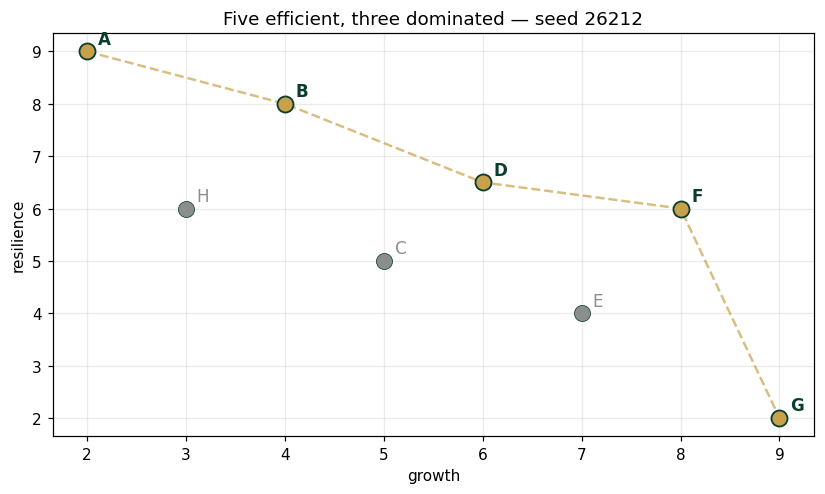

Pareto set: ['A', 'B', 'D', 'F', 'G']   dominated: ['C', 'E', 'H']


In [2]:
fig, ax = plt.subplots(figsize=(7.6,4.6))
for n,(g,r) in PTS.items():
    on = n in pareto_set()
    ax.scatter([g],[r], s=110, c="#C8A24B" if on else "#8A8F8B", zorder=5,
               edgecolors="#0B3D2E", linewidths=1.2 if on else 0.5)
    ax.annotate(n, (g,r), textcoords="offset points", xytext=(7,5), fontsize=11,
                color="#0B3D2E" if on else "#8A8F8B", fontweight="bold" if on else "normal")
ps = sorted([PTS[n] for n in pareto_set()])
ax.plot([p[0] for p in ps],[p[1] for p in ps], "--", c="#C8A24B", lw=1.6, alpha=.7)
ax.set(xlabel="growth", ylabel="resilience", title="Five efficient, three dominated — seed 26212")
ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"Pareto set: {pareto_set()}   dominated: {[n for n in NAMES if dominated(n)]}")

## Panel 2 — The scalarization gap, and the compromise that closes it
The Weighted-Sum Representation Theorem selects only points on the frontier's
*convex* upper boundary. Policy D $(6, 6.5)$ is Pareto-optimal but sits in a
**dent** — sweeping the weight $w$ across all 21 grid values, D wins
**zero** times: some efficient policies are invisible to every weighted sum.
The Enterprise Compromise Solution (Def.): minimize the weighted Chebyshev
distance to the ideal point $(9, 9)$ with stakeholder weights $(1, 1.5)$ —
and **D wins** (3.75 against F's 4.5). Stakeholder Preferences Select Among
Pareto-Optimal Solutions (Prop.), with a method whose reach covers the whole
frontier.

In [3]:
winners = [ws_winner(round(0.05*i,2)) for i in range(21)]
print("weighted-sum winners across w = 0.00 .. 1.00:", "".join(winners))
print(f"D selected by any weighted sum: {bool(ws_selects_D())}")
print(f"\nweighted Chebyshev to ideal (9,9), weights (1, 1.5):")
for n in pareto_set(): print(f"  {n}: {cheb(n):.4f}")
print(f"compromise winner: {cheb_winner()} — the dent, reached")

weighted-sum winners across w = 0.00 .. 1.00: AAAAAAAFFFFFFFFFFGGGG
D selected by any weighted sum: False

weighted Chebyshev to ideal (9,9), weights (1, 1.5):
  A: 7.0000
  B: 5.0000
  D: 3.7500
  F: 4.5000
  G: 10.5000
compromise winner: D — the dent, reached


## Panel 3 — The continuous frontier and the trade-off identity
Objectives $f_1 = x$, $f_2 = 1 - x^2$ on $[0, 1]$: every $x$ is efficient
(Pareto Frontier Existence Theorem). The weighted sum $wf_1 + (1-w)f_2$ has
interior optimum $x^*(w) = w/2(1-w)$ — at $w = 0.5$: $x^* = 0.5$,
$(f_1, f_2) = (0.5, 0.75)$, and the frontier's slope there is
$df_2/df_1 = -2x = -1$: exactly $-w/(1-w)$ — the **Enterprise Trade-Off
Theorem**: the chosen point is where the frontier's exchange rate equals the
decision-maker's. Past $w = 2/3$ the optimum hits the corner $x = 1$: strong
enough growth preference exhausts the frontier (first grid $w$: 0.7).

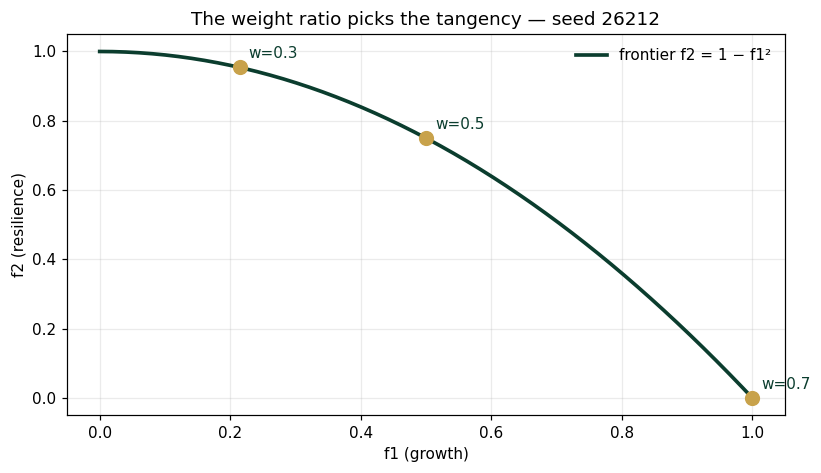

w=0.5: x* = 0.5000, f = (0.5000, 0.7500), slope = -1.0000
corner reached at grid w = 0.7


In [4]:
xs = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(7.6,4.4))
ax.plot(xs, 1-xs**2, c="#0B3D2E", lw=2.4, label="frontier f2 = 1 − f1²")
for w in (0.3, 0.5, 0.7):
    x = x_star(w)
    ax.scatter([x],[1-x*x], s=80, c="#C8A24B", zorder=5)
    ax.annotate(f"w={w}", (x,1-x*x), textcoords="offset points", xytext=(6,6), fontsize=10, color="#0B3D2E")
ax.set(xlabel="f1 (growth)", ylabel="f2 (resilience)", title="The weight ratio picks the tangency — seed 26212")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"w=0.5: x* = {x_star(0.5):.4f}, f = ({x_star(0.5):.4f}, {1-x_star(0.5)**2:.4f}), slope = {-2*x_star(0.5):.4f}")
print(f"corner reached at grid w = {w_corner()}")

## Validation — agrees with `DCT_V2_Ch12_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"n_candidates":8,"n_pareto":5,"n_dominated":3,"D_is_pareto":1,"ws_selects_D":0,
 "cheb_D":3.75,"cheb_F":4.5,"cheb_winner_is_D":1,"x_star_w05":0.5,"f1_w05":0.5,
 "f2_w05":0.75,"tradeoff_w05":-1.0,"w_corner":0.7}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:18s} {ref[k]}")
print("\nAll checkpoints agree — seed 26212.")

PASS  n_candidates       8
PASS  n_pareto           5
PASS  n_dominated        3
PASS  D_is_pareto        1
PASS  ws_selects_D       0
PASS  cheb_D             3.75
PASS  cheb_F             4.5
PASS  cheb_winner_is_D   1
PASS  x_star_w05         0.5
PASS  f1_w05             0.5
PASS  f2_w05             0.75
PASS  tradeoff_w05       -1.0
PASS  w_corner           0.7

All checkpoints agree — seed 26212.


**Next**: Exercises 12.5–12.9 (Part C) bend the dent deeper and watch goal programming and evolutionary methods handle it; AXIOM-12's frontier studio lets stakeholders drag the reference point live. Chapter 13 sends optimization to learn: machine learning. Solutions: IM Vol. II, Ch. 12.